In [1]:
# Put Home Credit Default Risk zip in your Google Drive
# Then mount your drive to colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Unzip the zip in your Google Drive
!unzip "/content/drive/MyDrive/home-credit-default-risk.zip" -d "/content/homerisk"

Archive:  /content/drive/MyDrive/home-credit-default-risk.zip
  inflating: /content/homerisk/HomeCredit_columns_description.csv  
  inflating: /content/homerisk/POS_CASH_balance.csv  
  inflating: /content/homerisk/application_test.csv  
  inflating: /content/homerisk/application_train.csv  
  inflating: /content/homerisk/bureau.csv  
  inflating: /content/homerisk/bureau_balance.csv  
  inflating: /content/homerisk/credit_card_balance.csv  
  inflating: /content/homerisk/installments_payments.csv  
  inflating: /content/homerisk/previous_application.csv  
  inflating: /content/homerisk/sample_submission.csv  


In [3]:
# Load all Home Credit dataset CSV files into pandas DataFrames

import pandas as pd

train = pd.read_csv("/content/homerisk/application_train.csv")
test = pd.read_csv("/content/homerisk/application_test.csv")

bureau = pd.read_csv("/content/homerisk/bureau.csv")
bureau_balance = pd.read_csv("/content/homerisk/bureau_balance.csv")

prev_app = pd.read_csv("/content/homerisk/previous_application.csv")

pos_cash = pd.read_csv("/content/homerisk/POS_CASH_balance.csv")

credit_card = pd.read_csv("/content/homerisk/credit_card_balance.csv")

installments = pd.read_csv("/content/homerisk/installments_payments.csv")

In [4]:
# Separate features (X) and target variable (y) for model training

TARGET = "TARGET" # name of the prediction label column
X = train.drop(columns=[TARGET]) # remove target column to get input features
y = train[TARGET] # extract target values (loan default: 0 or 1)

In [5]:
# Handle missing values by filling numeric columns with their median values

medians = X.median(numeric_only=True)

X = X.fillna(medians)
test = test.fillna(medians)

In [6]:
# Convert categorical variables into numeric format using one-hot encoding, then align train/test columns

X = pd.get_dummies(X) # convert categorical features in training set into binary indicator columns
test = pd.get_dummies(test) # do the same for test set

X, test = X.align(test, join="outer", axis=1, fill_value=0) # ensure both datasets have identical columns

In [7]:
# Aggregation Function
def make_features(df, group_col, prefix, agg_map):
    """
    Reusable function to aggregate any table to one row per applicant.
    """
    # apply aggregation functions per group (e.g., mean, sum)
    grouped = df.groupby(group_col).agg(agg_map)

    # flatten MultiIndex column names into readable feature names
    grouped.columns = [f"{prefix}_{c[0]}_{c[1]}" for c in grouped.columns]

    # bring group column back as a normal column
    grouped.reset_index(inplace=True)

    return grouped

In [8]:
# Aggregate bureau credit history
bureau_feat = make_features(
    bureau,
    "SK_ID_CURR",
    "bureau",
    {
        "DAYS_CREDIT": ["mean", "min", "max", "std"],
        "CREDIT_DAY_OVERDUE": ["max"],
        "AMT_CREDIT_SUM": ["sum", "mean"]
    }
)

In [9]:
# Aggregate previous loan applications
prev_feat = make_features(
    prev_app,
    "SK_ID_CURR",
    "prev",
    {
        "AMT_CREDIT": ["mean", "sum"],
        "AMT_ANNUITY": ["mean"],
        "DAYS_DECISION": ["min", "mean", "max"]
    }
)

In [10]:
# Aggregate POS CASH balance history
pos_feat = make_features(
    pos_cash,
    "SK_ID_CURR",
    "pos",
    {
        "CNT_INSTALMENT": ["mean", "std"],
        "CNT_INSTALMENT_FUTURE": ["mean"],
        "MONTHS_BALANCE": ["min", "max"]
    }
)

In [11]:
# Aggregate credit card balance behavior
cc_feat = make_features(
    credit_card,
    "SK_ID_CURR",
    "cc",
    {
        "AMT_BALANCE": ["mean", "max", "std"],
        "AMT_PAYMENT_TOTAL_CURRENT": ["mean", "sum"]
    }
)

In [12]:
# Aggregate installment payment history
installments["PAYMENT_RATIO"] = installments["AMT_PAYMENT"] / (installments["AMT_INSTALMENT"] + 1e-6)

inst_feat = make_features(
    installments,
    "SK_ID_CURR",
    "inst",
    {
        "AMT_PAYMENT": ["mean", "sum", "std"],
        "AMT_INSTALMENT": ["mean"],
        "PAYMENT_RATIO": ["mean", "std"]
    }
)

In [13]:
# Merge all engineered feature tables into the main dataset (train and test)

features = [bureau_feat, prev_feat, pos_feat, cc_feat, inst_feat]

for f in features:
    X = X.merge(f, on="SK_ID_CURR", how="left") # join feature table to training data using applicant ID
    test = test.merge(f, on="SK_ID_CURR", how="left") # apply same merge to test data to keep structure consistent

In [14]:
# Fill remaining missing values (NaN) with 0 after feature engineering and merging

X = X.fillna(0)
test = test.fillna(0)

In [15]:
# Split dataset into training and validation sets while preserving class balance

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y            # preserves class imbalance ratio (important for default prediction)
)

In [16]:
# Model Dictionary
models = {}

In [17]:
# Logistic Regression

# Train Logistic Regression model with feature scaling and evaluate using AUC

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

lr = LogisticRegression(max_iter=5000, C=0.5, class_weight="balanced")
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict_proba(X_val_scaled)[:, 1]
print("LR AUC:", roc_auc_score(y_val, lr_preds))

LR AUC: 0.7613133421089013


In [18]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict_proba(X_val)[:, 1]
print("RF AUC:", roc_auc_score(y_val, rf_preds))

RF AUC: 0.7349829577497753


In [19]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

gb_preds = gb.predict_proba(X_val)[:, 1]
print("GB AUC:", roc_auc_score(y_val, gb_preds))

GB AUC: 0.7680486209366019


In [20]:
# XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    tree_method="hist",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="auc",
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict_proba(X_val)[:, 1]
print("XGB AUC:", roc_auc_score(y_val, xgb_preds))

XGB AUC: 0.7779437490855815


In [21]:
# Extra Trees Classifier
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train, y_train)

et_preds = et.predict_proba(X_val)[:, 1]

print("Extra Trees AUC:", roc_auc_score(y_val, et_preds))

Extra Trees AUC: 0.7242230617328125


In [22]:
# HistGradientBoosting Classifier
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    random_state=42
)

hgb.fit(X_train, y_train)

hgb_preds = hgb.predict_proba(X_val)[:, 1]

print("HistGradientBoosting AUC:", roc_auc_score(y_val, hgb_preds))

HistGradientBoosting AUC: 0.774735465638934


In [23]:
# TensorFlow Neural Network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Neural networks work better with scaled data
nn_model = Sequential([
    Dense(256, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),

    Dense(1, activation="sigmoid")
])

nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC"]
)

nn_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=10,
    batch_size=1024,
    verbose=1
)

nn_preds = nn_model.predict(X_val_scaled).flatten()

print("Neural Net AUC:", roc_auc_score(y_val, nn_preds))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - AUC: 0.6961 - loss: 0.2657 - val_AUC: 0.7495 - val_loss: 0.2612
Epoch 2/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - AUC: 0.7405 - loss: 0.2525 - val_AUC: 0.7543 - val_loss: 0.2481
Epoch 3/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - AUC: 0.7508 - loss: 0.2492 - val_AUC: 0.7558 - val_loss: 0.2530
Epoch 4/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - AUC: 0.7572 - loss: 0.2474 - val_AUC: 0.7535 - val_loss: 0.2528
Epoch 5/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - AUC: 0.7634 - loss: 0.2453 - val_AUC: 0.7552 - val_loss: 0.2544
Epoch 6/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - AUC: 0.7657 - loss: 0.2442 - val_AUC: 0.7566 - val_loss: 0.2519
Epoch 7/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - AUC: 0.7692 - loss: 0.2431 - val_AUC: 0.7553 - val_loss: 0.2498
Epoch 8/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - AUC: 0.7734 - loss: 0.2417 - val_AUC: 0.7567 - val_loss: 0.2491
Epoch 9/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 22

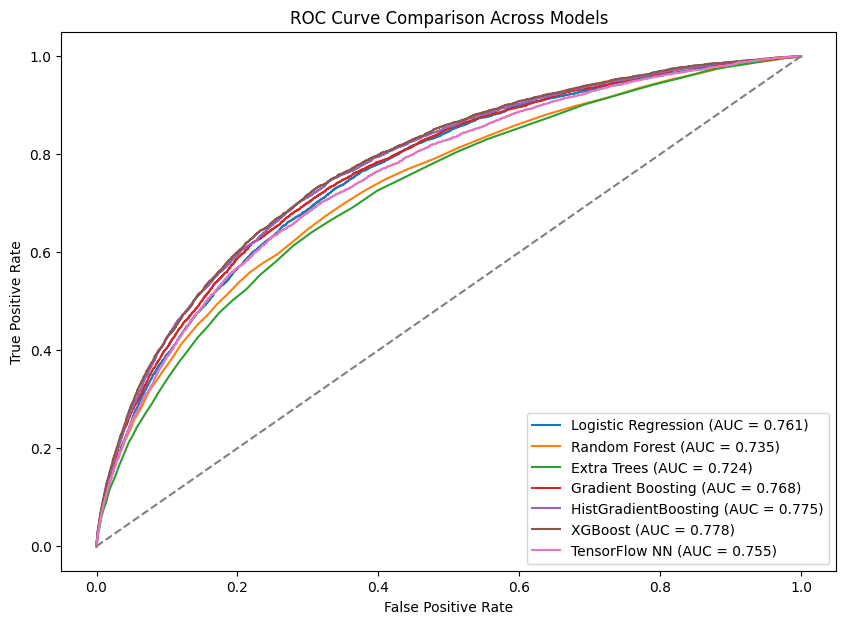

In [24]:
# ROC Curve Comparison for All Models

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

models = {
    "Logistic Regression": (lr, X_val_scaled),
    "Random Forest": (rf, X_val),
    "Extra Trees": (et, X_val),
    "Gradient Boosting": (gb, X_val),
    "HistGradientBoosting": (hgb, X_val),
    "XGBoost": (xgb, X_val)
}

plt.figure(figsize=(10,7))

# Plot sklearn-style models
for name, (model, Xdata) in models.items():

    preds = model.predict_proba(Xdata)[:, 1]

    auc = roc_auc_score(y_val, preds)

    fpr, tpr, _ = roc_curve(y_val, preds)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

# Add Neural Network separately
nn_auc = roc_auc_score(y_val, nn_preds)
nn_fpr, nn_tpr, _ = roc_curve(y_val, nn_preds)

plt.plot(nn_fpr, nn_tpr,
         label=f"TensorFlow NN (AUC = {nn_auc:.3f})")

# Random baseline
plt.plot([0,1], [0,1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison Across Models")
plt.legend()

plt.show()

In [25]:
best_model = xgb
best_model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [26]:
test_preds = best_model.predict_proba(test)[:, 1]

submission = pd.DataFrame({
    "SK_ID_CURR": test["SK_ID_CURR"],
    "TARGET": test_preds
})

submission.to_csv("submission.csv", index=False)

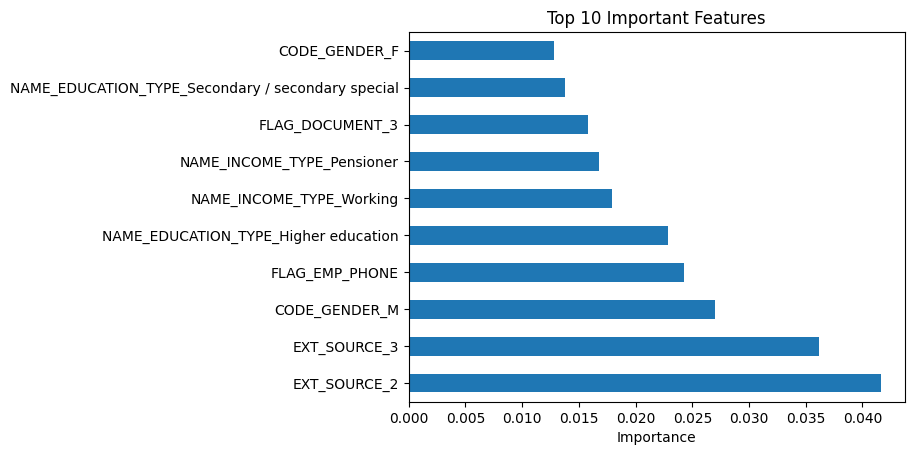

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
)

top10 = importance.sort_values(ascending=False).head(10)

top10.plot(kind="barh")

plt.title("Top 10 Important Features")
plt.xlabel("Importance")

plt.show()